<a href="https://colab.research.google.com/github/nora-mohamed25/data-analysis-portfolio/blob/main/Project_08_Social_Media_Engagement.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# SOCIAL MEDIA

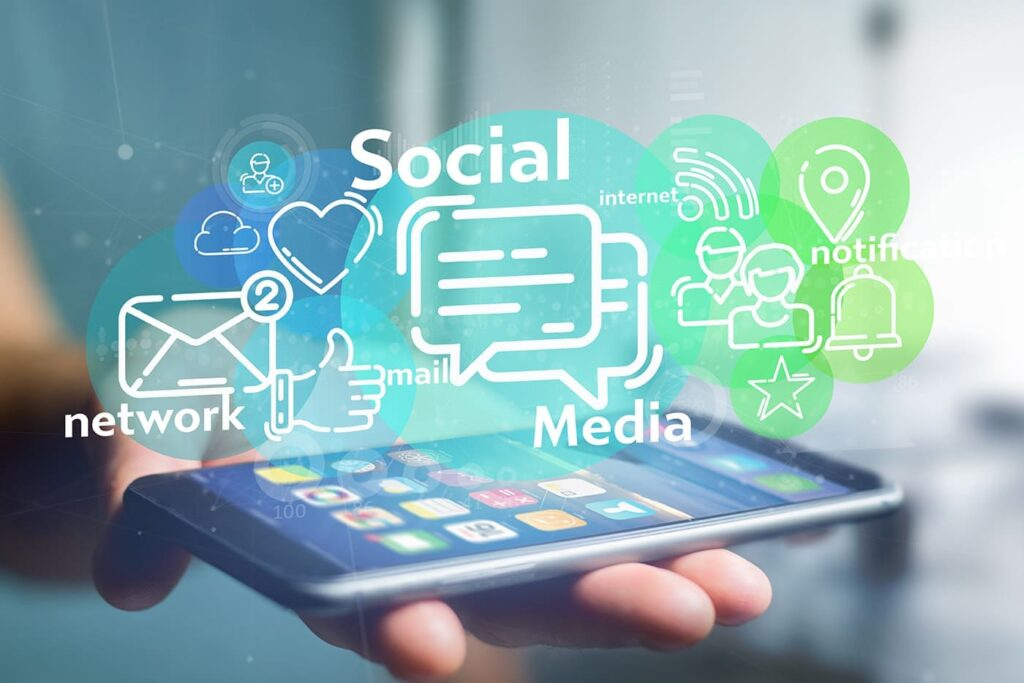

---



In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import   r2_score, mean_squared_error, mean_absolute_error
import numpy as np
from sklearn.metrics import accuracy_score

In [ ]:
df = pd.read_csv('/content/social_media_engagement.csv')

In [ ]:
df.head()

,platform,post_type,post_length,views,likes,comments,shares,engagement_rate
0,Facebook,Text,62,91660,2968,276,346,0.039166
1,Instagram,Video,104,113115,4164,632,406,0.045989
2,Facebook,Video,46,36043,3125,188,100,0.094692
3,Facebook,Image,39,124886,5970,948,578,0.060023
4,Instagram,Video,42,82831,8212,1104,334,0.116502


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   platform         10000 non-null  object 
 1   post_type        10000 non-null  object 
 2   post_length      10000 non-null  int64  
 3   views            10000 non-null  int64  
 4   likes            10000 non-null  int64  
 5   comments         10000 non-null  int64  
 6   shares           10000 non-null  int64  
 7   engagement_rate  10000 non-null  float64
dtypes: float64(1), int64(5), object(2)
memory usage: 625.1+ KB


In [ ]:
df['platform'] = df['platform'].map({'Facebook': 0, 'Instagram': 1})
df['post_type'] = df['post_type'].map({'Photo': 0, 'Video': 1})

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   platform         6653 non-null   float64
 1   post_type        3333 non-null   float64
 2   post_length      10000 non-null  int64  
 3   views            10000 non-null  int64  
 4   likes            10000 non-null  int64  
 5   comments         10000 non-null  int64  
 6   shares           10000 non-null  int64  
 7   engagement_rate  10000 non-null  float64
dtypes: float64(3), int64(5)
memory usage: 625.1 KB


In [ ]:
scaler = MinMaxScaler()
df['post_length'] = scaler.fit_transform(df[['post_length']])
df['likes'] = scaler.fit_transform(df[['likes']])
df['comments'] = scaler.fit_transform(df[['comments']])
df['shares'] = scaler.fit_transform(df[['shares']])
df['views'] = scaler.fit_transform(df[['views']])

In [ ]:
df.head()

,platform,post_type,post_length,views,likes,comments,shares,engagement_rate
0,0.0,NaN,0.500000,0.300737,0.099589,0.050258,0.089142,0.039166
1,1.0,1.0,0.868421,0.372749,0.140199,0.115795,0.104690,0.045989
2,0.0,1.0,0.359649,0.114064,0.104920,0.034057,0.025395,0.094692
3,0.0,NaN,0.298246,0.412257,0.201521,0.173969,0.149261,0.060023
4,1.0,1.0,0.324561,0.271103,0.277648,0.202688,0.086033,0.116502


In [ ]:
df.isnull().sum()

,0
platform,3347
post_type,6667
post_length,0
views,0
likes,0
comments,0
shares,0
engagement_rate,0


In [ ]:
df['platform'].fillna(df['platform'].mode()[0], inplace=True)
df['post_type'].fillna(df['post_type'].mode()[0], inplace=True)

/tmp/ipython-input-2330535287.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['platform'].fillna(df['platform'].mode()[0], inplace=True)
/tmp/ipython-input-2330535287.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=T

In [ ]:
df.isnull().sum()

,0
platform,0
post_type,0
post_length,0
views,0
likes,0
comments,0
shares,0
engagement_rate,0


In [ ]:
x = df.drop('engagement_rate', axis=1)
y = df['engagement_rate']

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [ ]:
model = DecisionTreeClassifier()

In [ ]:
from sklearn.tree import DecisionTreeRegressor

model = DecisionTreeRegressor()
model.fit(x_train_encoded, y_train)

DecisionTreeRegressor()

In [ ]:
y_pred = model.predict(x_test_encoded)


In [ ]:
y_pred

array([0.06761497, 0.07008735, 0.04864111, ..., 0.03175281, 0.10768897,
       0.055671  ])

In [ ]:
df.compare = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
df.compare

,Actual,Predicted
6252,0.070609,0.067615
4684,0.067116,0.070087
1731,0.055756,0.048641
4742,0.117102,0.120183
4521,0.079012,0.074428
...,...,...
6412,0.074058,0.073198
8285,0.100920,0.106750
7853,0.027449,0.031753
1095,0.104617,0.107689


In [ ]:
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

In [ ]:
mse

2.1138914081234868e-05

In [ ]:
r2

0.9791303470031318